# Materials preprocessing & featurization basic(Assignment)



## **Step 0 : Data retrieval and filtering**





In [1]:
# Install libraries to use matminer.
!pip install --upgrade matplotlib==3.8.0
!pip install --upgrade pyyaml six matminer[citrine] citrination-client pymatgen

# This will restart the environment, allowing you to re-run the code with the correct versions.
#import os
#os.kill(os.getpid(), 9)

# Ignore the warning message
import warnings
warnings.filterwarnings('ignore')

# Load the required libraries
import numpy as np # a software library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays.
import pandas as pd # a software library written for the Python programming language for data manipulation and analysis. In particular, it offers data structures and operations for manipulating numerical tables and time series
import matplotlib.pyplot as plt # a plotting library for the Python programming language
import seaborn as sns # Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics

# sklearn is a machine learning software library for the Python programming language. It features various classification, regression and clustering algorithms including support vector machines, random forests, gradient boosting,
# k-means and DBSCAN, and is designed to interoperate with the Python numerical and scientific libraries NumPy and SciPy.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

In [2]:
# All datasets can be loaded using the load_dataset() function and the database name.
from matminer.datasets import load_dataset

df = load_dataset("dielectric_constant")

Fetching dielectric_constant.json.gz from https://ndownloader.figshare.com/files/13213475 to /usr/local/lib/python3.12/dist-packages/matminer/datasets/dielectric_constant.json.gz


Fetching https://ndownloader.figshare.com/files/13213475 in MB: 0.8867839999999999MB [00:00, 130.81MB/s]      


In [3]:
# We can get some more detailed information about this dataset using the get_all_dataset_info(<dataset>) function from matminer.
from matminer.datasets import get_all_dataset_info

print(get_all_dataset_info("dielectric_constant"))

Dataset: dielectric_constant
Description: 1,056 structures with dielectric properties, calculated with DFPT-PBE.
Columns:
	band_gap: Measure of the conductivity of a material
	cif: optional: Description string for structure
	e_electronic: electronic contribution to dielectric tensor
	e_total: Total dielectric tensor incorporating both electronic and ionic contributions
	formula: Chemical formula of the material
	material_id: Materials Project ID of the material
	meta: optional, metadata descriptor of the datapoint
	n: Refractive Index
	nsites: The \# of atoms in the unit cell of the calculation.
	poly_electronic: the average of the eigenvalues of the electronic contribution to the dielectric tensor
	poly_total: the average of the eigenvalues of the total (electronic and ionic) contributions to the dielectric tensor
	poscar: optional: Poscar metadata
	pot_ferroelectric: Whether the material is potentially ferroelectric
	space_group: Integer specifying the crystallographic structure of t

## **Step 1: Use the conversions Featurizers in matminer to turn a String composition**

In [4]:
from matminer.featurizers.conversions import StrToComposition

In [6]:
# Add composition-based features
# A major class of featurizers available in matminer uses the chemical composition to featurize the input data.
# Let's add some composition based features to our DataFrame.

# First step : Using the conversions Featurizers in matminer to turn a String composition (our formula column from before) into a pymatgen Composition.
df1 = StrToComposition().featurize_dataframe(df, "formula")
df1.head()


StrToComposition:   0%|          | 0/1056 [00:00<?, ?it/s]

,material_id,formula,nsites,space_group,volume,structure,band_gap,e_electronic,e_total,n,poly_electronic,poly_total,pot_ferroelectric,cif,meta,poscar,composition
0,mp-441,Rb2Te,3,225,159.501208,"[[1.75725875 1.2425695 3.04366125] Rb, [5.271...",1.88,"[[3.44115795, -3.097e-05, -6.276e-05], [-2.837...","[[6.23414745, -0.00035252, -9.796e-05], [-0.00...",1.86,3.44,6.23,False,#\#CIF1.1\n###################################...,{u'incar': u'NELM = 100\nIBRION = 8\nLWAVE = F...,Rb2 Te1\n1.0\n5.271776 0.000000 3.043661\n1.75...,"(Rb, Te)"
1,mp-22881,CdCl2,3,166,84.298097,"[[0. 0. 0.] Cd, [ 4.27210959 2.64061969 13.13...",3.52,"[[3.34688382, -0.04498543, -0.22379197], [-0.0...","[[7.97018673, -0.29423886, -1.463590159999999]...",1.78,3.16,6.73,False,#\#CIF1.1\n###################################...,{u'incar': u'NELM = 100\nIBRION = 8\nLWAVE = F...,Cd1 Cl2\n1.0\n3.850977 0.072671 5.494462\n1.78...,"(Cd, Cl)"
2,mp-28013,MnI2,3,164,108.335875,"[[0. 0. 0.] Mn, [-2.07904300e-06 2.40067320e+...",1.17,"[[5.5430849, -5.28e-06, -2.5030000000000003e-0...","[[13.80606079, 0.0006911900000000001, 9.655e-0...",2.23,4.97,10.64,False,#\#CIF1.1\n###################################...,{u'incar': u'NELM = 100\nIBRION = 8\nLWAVE = F...,Mn1 I2\n1.0\n4.158086 0.000000 0.000000\n-2.07...,"(Mn, I)"
3,mp-567290,LaN,4,186,88.162562,[[-1.73309900e-06 2.38611186e+00 5.95256328e...,1.12,"[[7.09316738, 7.99e-06, -0.0003864700000000000...","[[16.79535386, 8.199999999999997e-07, -0.00948...",2.65,7.04,17.99,False,#\#CIF1.1\n###################################...,{u'incar': u'NELM = 100\nIBRION = 8\nLWAVE = F...,La2 N2\n1.0\n4.132865 0.000000 0.000000\n-2.06...,"(La, N)"
4,mp-560902,MnF2,6,136,82.826401,"[[1.677294 2.484476 2.484476] Mn, [0. 0. 0.] M...",2.87,"[[2.4239622, 7.452000000000001e-05, 6.06100000...","[[6.44055613, 0.0020446600000000002, 0.0013203...",1.53,2.35,7.12,False,#\#CIF1.1\n###################################...,{u'incar': u'NELM = 100\nIBRION = 8\nLDAUTYPE ...,Mn2 F4\n1.0\n3.354588 0.000000 0.000000\n0.000...,"(Mn, F)"


Step 2 : Using one of the featurizers in matminer to add a suite of descriptors to the DataFrame.

In [7]:
from matminer.featurizers.composition import ElementProperty

# Add Magpie feature set
ep_feat = ElementProperty.from_preset("magpie")
df2 = ep_feat.featurize_dataframe(df1, col_id="composition")
df2.head()

ElementProperty:   0%|          | 0/1056 [00:00<?, ?it/s]

,material_id,formula,nsites,space_group,volume,structure,band_gap,e_electronic,e_total,n,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,mp-441,Rb2Te,3,225,159.501208,"[[1.75725875 1.2425695 3.04366125] Rb, [5.271...",1.88,"[[3.44115795, -3.097e-05, -6.276e-05], [-2.837...","[[6.23414745, -0.00035252, -9.796e-05], [-0.00...",1.86,...,0.00000,0.000000,0.000000,0.0,152.0,229.0,77.0,203.333333,34.222222,229.0
1,mp-22881,CdCl2,3,166,84.298097,"[[0. 0. 0.] Cd, [ 4.27210959 2.64061969 13.13...",3.52,"[[3.34688382, -0.04498543, -0.22379197], [-0.0...","[[7.97018673, -0.29423886, -1.463590159999999]...",1.78,...,0.00000,0.000000,0.000000,0.0,64.0,194.0,130.0,107.333333,57.777778,64.0
2,mp-28013,MnI2,3,164,108.335875,"[[0. 0. 0.] Mn, [-2.07904300e-06 2.40067320e+...",1.17,"[[5.5430849, -5.28e-06, -2.5030000000000003e-0...","[[13.80606079, 0.0006911900000000001, 9.655e-0...",2.23,...,0.00031,0.000103,0.000138,0.0,64.0,217.0,153.0,115.000000,68.000000,64.0
3,mp-567290,LaN,4,186,88.162562,[[-1.73309900e-06 2.38611186e+00 5.95256328e...,1.12,"[[7.09316738, 7.99e-06, -0.0003864700000000000...","[[16.79535386, 8.199999999999997e-07, -0.00948...",2.65,...,0.00000,0.000000,0.000000,0.0,194.0,194.0,0.0,194.000000,0.000000,194.0
4,mp-560902,MnF2,6,136,82.826401,"[[1.677294 2.484476 2.484476] Mn, [0. 0. 0.] M...",2.87,"[[2.4239622, 7.452000000000001e-05, 6.06100000...","[[6.44055613, 0.0020446600000000002, 0.0013203...",1.53,...,0.00031,0.000103,0.000138,0.0,15.0,217.0,202.0,82.333333,89.777778,15.0


## **Step 3: Add more composition-based featurizers**

In [8]:
from matminer.featurizers.conversions import CompositionToOxidComposition
from matminer.featurizers.composition import OxidationStates

In [9]:
# Add more composition-based features
# There are many more Composition based featurizers apart from ElementProperty that are available in the matminer.featurizers.composition.
# Let's try the ElectronegativityDiff featurizer which requires knowing the oxidation state of the various elements in the Composition.
df3 = CompositionToOxidComposition().featurize_dataframe(df2, "composition")
df3.head()

CompositionToOxidComposition:   0%|          | 0/1056 [00:00<?, ?it/s]

,material_id,formula,nsites,space_group,volume,structure,band_gap,e_electronic,e_total,n,...,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid
0,mp-441,Rb2Te,3,225,159.501208,"[[1.75725875 1.2425695 3.04366125] Rb, [5.271...",1.88,"[[3.44115795, -3.097e-05, -6.276e-05], [-2.837...","[[6.23414745, -0.00035252, -9.796e-05], [-0.00...",1.86,...,0.000000,0.000000,0.0,152.0,229.0,77.0,203.333333,34.222222,229.0,"(Rb+, Te2-)"
1,mp-22881,CdCl2,3,166,84.298097,"[[0. 0. 0.] Cd, [ 4.27210959 2.64061969 13.13...",3.52,"[[3.34688382, -0.04498543, -0.22379197], [-0.0...","[[7.97018673, -0.29423886, -1.463590159999999]...",1.78,...,0.000000,0.000000,0.0,64.0,194.0,130.0,107.333333,57.777778,64.0,"(Cd2+, Cl-)"
2,mp-28013,MnI2,3,164,108.335875,"[[0. 0. 0.] Mn, [-2.07904300e-06 2.40067320e+...",1.17,"[[5.5430849, -5.28e-06, -2.5030000000000003e-0...","[[13.80606079, 0.0006911900000000001, 9.655e-0...",2.23,...,0.000103,0.000138,0.0,64.0,217.0,153.0,115.000000,68.000000,64.0,"(Mn2+, I-)"
3,mp-567290,LaN,4,186,88.162562,[[-1.73309900e-06 2.38611186e+00 5.95256328e...,1.12,"[[7.09316738, 7.99e-06, -0.0003864700000000000...","[[16.79535386, 8.199999999999997e-07, -0.00948...",2.65,...,0.000000,0.000000,0.0,194.0,194.0,0.0,194.000000,0.000000,194.0,"(La3+, N3-)"
4,mp-560902,MnF2,6,136,82.826401,"[[1.677294 2.484476 2.484476] Mn, [0. 0. 0.] M...",2.87,"[[2.4239622, 7.452000000000001e-05, 6.06100000...","[[6.44055613, 0.0020446600000000002, 0.0013203...",1.53,...,0.000103,0.000138,0.0,15.0,217.0,202.0,82.333333,89.777778,15.0,"(Mn2+, F-)"


In [10]:
# Add statistical features of oxidation states
from matminer.featurizers.composition import OxidationStates
os_feat = OxidationStates()
df4 = os_feat.featurize_dataframe(df3, "composition_oxid")
df4.head()

OxidationStates:   0%|          | 0/1056 [00:00<?, ?it/s]

,material_id,formula,nsites,space_group,volume,structure,band_gap,e_electronic,e_total,n,...,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid,minimum oxidation state,maximum oxidation state,range oxidation state,std_dev oxidation state
0,mp-441,Rb2Te,3,225,159.501208,"[[1.75725875 1.2425695 3.04366125] Rb, [5.271...",1.88,"[[3.44115795, -3.097e-05, -6.276e-05], [-2.837...","[[6.23414745, -0.00035252, -9.796e-05], [-0.00...",1.86,...,229.0,77.0,203.333333,34.222222,229.0,"(Rb+, Te2-)",-2,1,3,2.121320
1,mp-22881,CdCl2,3,166,84.298097,"[[0. 0. 0.] Cd, [ 4.27210959 2.64061969 13.13...",3.52,"[[3.34688382, -0.04498543, -0.22379197], [-0.0...","[[7.97018673, -0.29423886, -1.463590159999999]...",1.78,...,194.0,130.0,107.333333,57.777778,64.0,"(Cd2+, Cl-)",-1,2,3,2.121320
2,mp-28013,MnI2,3,164,108.335875,"[[0. 0. 0.] Mn, [-2.07904300e-06 2.40067320e+...",1.17,"[[5.5430849, -5.28e-06, -2.5030000000000003e-0...","[[13.80606079, 0.0006911900000000001, 9.655e-0...",2.23,...,217.0,153.0,115.000000,68.000000,64.0,"(Mn2+, I-)",-1,2,3,2.121320
3,mp-567290,LaN,4,186,88.162562,[[-1.73309900e-06 2.38611186e+00 5.95256328e...,1.12,"[[7.09316738, 7.99e-06, -0.0003864700000000000...","[[16.79535386, 8.199999999999997e-07, -0.00948...",2.65,...,194.0,0.0,194.000000,0.000000,194.0,"(La3+, N3-)",-3,3,6,4.242641
4,mp-560902,MnF2,6,136,82.826401,"[[1.677294 2.484476 2.484476] Mn, [0. 0. 0.] M...",2.87,"[[2.4239622, 7.452000000000001e-05, 6.06100000...","[[6.44055613, 0.0020446600000000002, 0.0013203...",1.53,...,217.0,202.0,82.333333,89.777778,15.0,"(Mn2+, F-)",-1,2,3,2.121320


## **Step 3: Add Structure based featurizers**

In [11]:
from matminer.featurizers.structure import DensityFeatures

df_feat = DensityFeatures()
df5 = df_feat.featurize_dataframe(df4, "structure")
df5.head()

DensityFeatures:   0%|          | 0/1056 [00:00<?, ?it/s]

,material_id,formula,nsites,space_group,volume,structure,band_gap,e_electronic,e_total,n,...,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,composition_oxid,minimum oxidation state,maximum oxidation state,range oxidation state,std_dev oxidation state,density,vpa,packing fraction
0,mp-441,Rb2Te,3,225,159.501208,"[[1.75725875 1.2425695 3.04366125] Rb, [5.271...",1.88,"[[3.44115795, -3.097e-05, -6.276e-05], [-2.837...","[[6.23414745, -0.00035252, -9.796e-05], [-0.00...",1.86,...,34.222222,229.0,"(Rb+, Te2-)",-2,1,3,2.121320,3.108002,53.167069,0.753707
1,mp-22881,CdCl2,3,166,84.298097,"[[0. 0. 0.] Cd, [ 4.27210959 2.64061969 13.13...",3.52,"[[3.34688382, -0.04498543, -0.22379197], [-0.0...","[[7.97018673, -0.29423886, -1.463590159999999]...",1.78,...,57.777778,64.0,"(Cd2+, Cl-)",-1,2,3,2.121320,3.611055,28.099366,0.284421
2,mp-28013,MnI2,3,164,108.335875,"[[0. 0. 0.] Mn, [-2.07904300e-06 2.40067320e+...",1.17,"[[5.5430849, -5.28e-06, -2.5030000000000003e-0...","[[13.80606079, 0.0006911900000000001, 9.655e-0...",2.23,...,68.000000,64.0,"(Mn2+, I-)",-1,2,3,2.121320,4.732379,36.111958,0.318289
3,mp-567290,LaN,4,186,88.162562,[[-1.73309900e-06 2.38611186e+00 5.95256328e...,1.12,"[[7.09316738, 7.99e-06, -0.0003864700000000000...","[[16.79535386, 8.199999999999997e-07, -0.00948...",2.65,...,0.000000,194.0,"(La3+, N3-)",-3,3,6,4.242641,5.760192,22.040641,0.730689
4,mp-560902,MnF2,6,136,82.826401,"[[1.677294 2.484476 2.484476] Mn, [0. 0. 0.] M...",2.87,"[[2.4239622, 7.452000000000001e-05, 6.06100000...","[[6.44055613, 0.0020446600000000002, 0.0013203...",1.53,...,89.777778,15.0,"(Mn2+, F-)",-1,2,3,2.121320,3.726395,13.804400,0.302832


## **Step 4: Select numeric data and perform preprocessing**

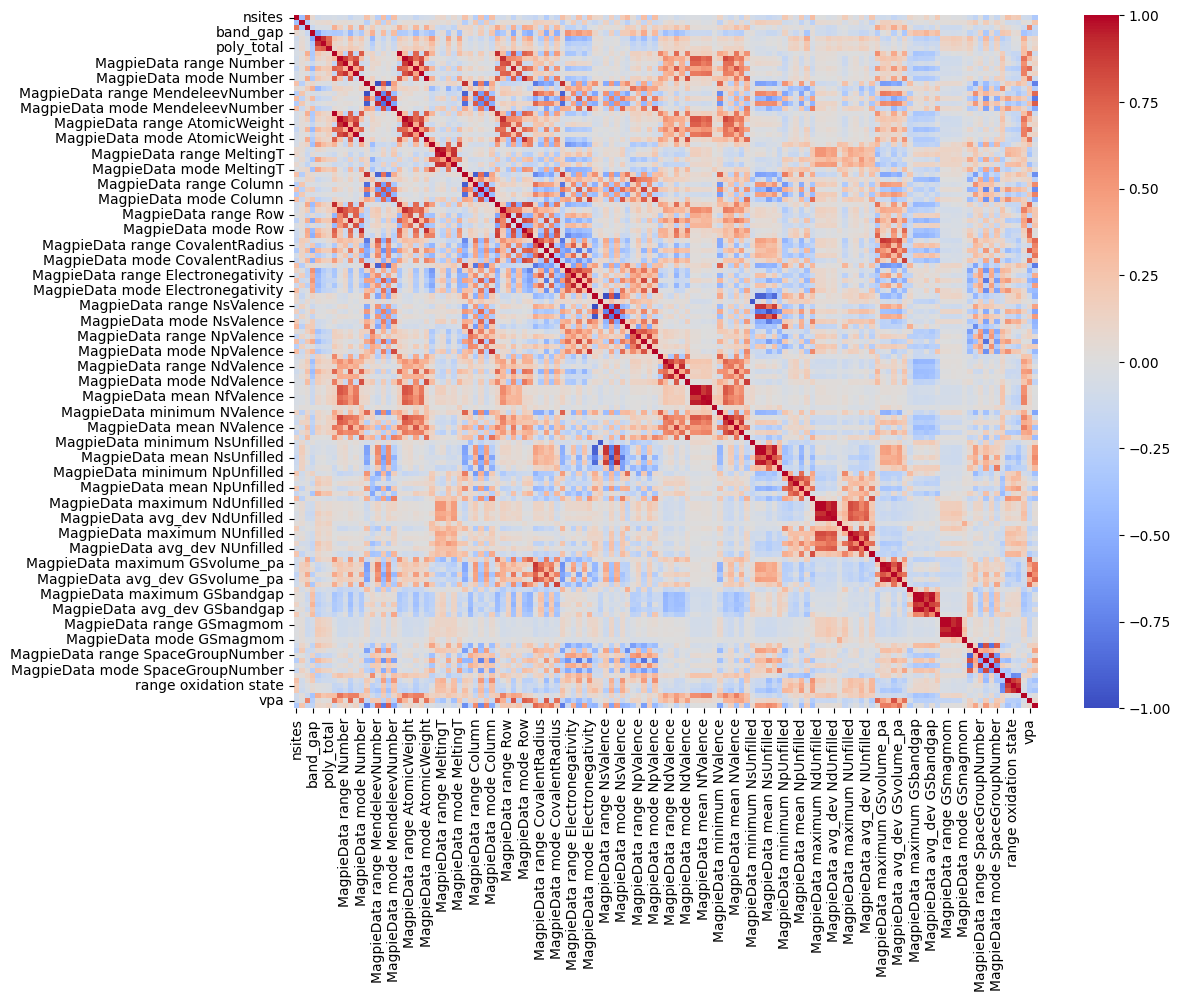

In [12]:
import numpy as np

# Select only the numeric columns for correlation
numeric_df = df5.select_dtypes(include=[np.number])
# Remove columns with a single unique value (which don't contribute to correlation)
numeric_df = numeric_df.loc[:, numeric_df.apply(lambda col: col.nunique() != 1)]

# Now plot the heatmap for the correlation matrix of numeric columns
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
plt.show()

In [13]:
def identify_columns(x_new, nrows=10):
    columns = numeric_df.columns
    xvalues = numeric_df.values
    dist = np.linalg.norm(xvalues[:nrows, :, None] - x_new[:nrows, None, :], axis=0)
    return columns[np.argmin(dist, axis=0)].values

In [14]:
x_data = numeric_df[numeric_df.columns.values]
y_data = numeric_df['poly_total']

In [15]:
sel = SelectKBest(f_regression, k=10)
x_new = sel.fit_transform(x_data, y_data)

mask = sel.get_support()
selected_columns = x_data.columns[mask]

print(f"Selected features: {selected_columns}")

Selected features: Index(['band_gap', 'n', 'poly_electronic', 'poly_total',
       'MagpieData mean Number', 'MagpieData mean AtomicWeight',
       'MagpieData minimum MeltingT', 'MagpieData mean Row',
       'MagpieData avg_dev NpUnfilled', 'density'],
      dtype='object')


Correlation of selected features with the target:
band_gap                        -0.274948
n                                0.711662
poly_electronic                  0.752717
MagpieData mean Number           0.216755
MagpieData mean AtomicWeight     0.216381
MagpieData minimum MeltingT      0.211892
MagpieData mean Row              0.219129
MagpieData avg_dev NpUnfilled    0.262576
density                          0.285535
Name: poly_total, dtype: float64


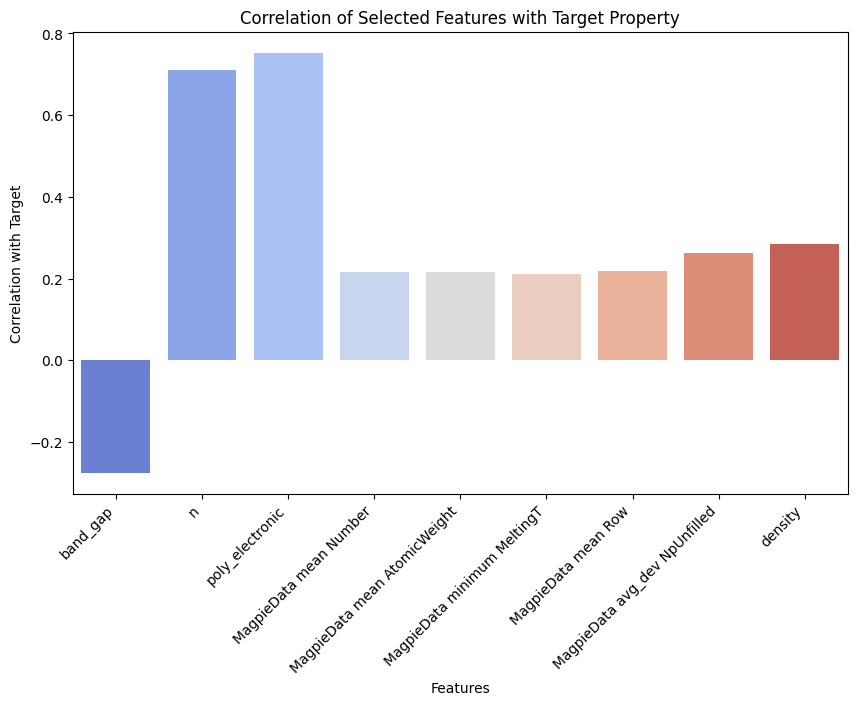

In [16]:
selected_features_df = numeric_df[selected_columns]
selected_features_df['poly_total'] = y_data
correlation_matrix = selected_features_df.corr()
target_correlation = correlation_matrix['poly_total'].drop('poly_total')

print("Correlation of selected features with the target:")
print(target_correlation)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_correlation.index, y=target_correlation.values, palette="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Correlation with Target')
plt.title('Correlation of Selected Features with Target Property')
plt.show()